# ⚖️ <font color='red'>偏差-方差权衡</font>
模型复杂度变化时，三项呈现此消彼长的关系：
- 模型过于简单：偏差高（欠拟合），方差低，总误差大。
- 模型过于复杂：偏差低，方差高（过拟合），总误差大。
- 最优复杂度：<font color='red'>偏差² + 方差之和最小，达到最佳泛化性能</font>

## 总误差的数学分解
对于任意一个模型，它在测试集上的期望误差可以分解为三项：



In [1]:
from IPython.display import Image

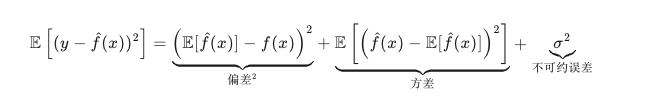

In [2]:
Image(filename='./Image/mse.png')

| 项         | 含义               | 能否消除          |
| --------- | ---------------- | ------------- |
| **偏差²**   | 模型预测的平均值与真实值的差距  | 可通过增加模型复杂度降低  |
| **方差**    | 模型预测在不同训练集上的波动程度 | 可通过简化模型/正则化降低 |
| **不可约误差** | 数据本身的噪声（如测量误差）   | ❌ 无法消除        |


# 三个区域的直观理解
## 🎯 用"打靶"比喻
想象你在射箭，靶心是真实规律，你的每一箭是用不同训练集训练出的模型：

| 情况          | 偏差                   | 方差       | 图示          |
| ----------- | -------------------- | -------- | ----------- |
| **高偏差，低方差** | 箭都集中在靶子**左下角**（偏离靶心） | 箭很**密集** | 🎯💨（<font color='red'>偏了但集中</font>） |
| **低偏差，高方差** | 箭**围绕靶心**分布          | 箭很**分散** | 🎯✨（<font color='blue'>准但不稳</font>）   |
| **最优**      | 箭**集中在靶心**           | 箭**密集**  | 🎯⭐（又准又稳）   |


# 逐区域详解 + 实例
## 区域1：模型过于简单 → <font color='blue'>高偏差，低方差（欠拟合）</font>
### 特征：
- <font color='red'>模型"太笨"，抓不住数据的真实规律</font>
- 换不同的训练集，学到的模型都差不多（方差低）
- <font color='blue'>但学出来的东西**离真相很远**（偏差高）</font>

### 典型例子：用直线拟合二次曲线

In [ ]:
真实规律: y = x² + ε（抛物线）
模型假设: ŷ = ax + b（强行用直线拟合）

训练集1 → 学到: ŷ = 2x + 1
训练集2 → 学到: ŷ = 2.1x + 0.9
训练集3 → 学到: ŷ = 1.9x + 1.1

特点:
  方差低: 三次结果很接近（斜率都在2附近）
  偏差高: 但直线根本拟合不了抛物线，系统性地偏离

### 现实中的表现：
- 用线性回归预测房价，但忽略了面积和价格的非线性关系
- 用浅层神经网络处理复杂图像
- 训练准确率就低，测试准确率也低

## 区域2：模型过于复杂 → <font color='blue'>低偏差，高方差（过拟合）</font>
### 特征：
- 模型"太聪明"，不仅学了规律，还学了噪声
- <font color='blue'>换一批训练数据，学到的模型差异很大（方差高）</font>
- <font color='blue'>对训练集拟合很好（偏差低）</font>，<font color='red'>但泛化差</font>

### 典型例子：用10次多项式拟合5个数据点
**特点:**
  - 偏差低: 训练集上误差几乎为0（<font color='blue'>完美穿过每个点</font>）
  - 方差高: 换一批数据，曲线形状完全不同

In [3]:
真实规律: y = x² + ε（抛物线 + 少量噪声）
模型假设: ŷ = a₀ + a₁x + a₂x² + ... + a₁₀x¹⁰（10次多项式）

训练集1（5个点）→ 曲线疯狂穿过每个点，扭来扭去
训练集2（换5个点）→ 完全不同的扭曲曲线
训练集3（再换5个点）→ 又一种扭曲



SyntaxError: invalid character '²' (U+00B2) (1809675876.py, line 1)

### 现实中的表现：
- 深度神经网络不加正则化，在小型数据集上训练
- 决策树不剪枝，每个叶子节点只有1个样本
- 训练准确率99%，测试准确率60%

## 区域3：最优复杂度 → 偏差² + 方差最小
### 特征：
- 模型复杂度"刚刚好"
- <font color='blue'>能捕捉主要规律，又不被噪声干扰</font>
- <font color='red'>**训练误差**和**测试误差**都较低且接近</font>

### 典型例子：用二次多项式拟合二次数据
**特点:**
  - 偏差低: 模型形式与真实规律匹配，预测接近真实值
  - 方差低: **不同训练集学到的参数很接近**
  - <font color='red'>总误差最小: 泛化性能最佳</font>

In [ ]:
真实规律: y = x² + ε
模型假设: ŷ = a₀ + a₁x + a₂x²（2次多项式）

训练集1 → 学到: ŷ ≈ 0.1 + 0.05x + 0.98x²
训练集2 → 学到: ŷ ≈ -0.05 + 0.02x + 1.02x²
训练集3 → 学到: ŷ ≈ 0.08 - 0.03x + 1.01x²


# U型曲线的完整图景

| 区域  | 模型     | 训练误差   | 测试误差   | 偏差 | 方差 |
| --- | ------ | ------ | ------ | -- | -- |
| 欠拟合 | 线性回归   | 高      | 高      | 高  | 低  |
| 最优  | 3次多项式  | 中      | **最低** | 中  | 中  |
| 过拟合 | 10次多项式 | **极低** | 高      | 低  | 高  |


In [ ]:
总误差
  ↑
  │    ╭────╮
  │   ╱ 最优  ╲
  │  ╱  点    ╲
  │ ╱            ╲ ← 过拟合区域
  │╱              ╲
  │                ╲
  │                 ╲
  │  ← 欠拟合区域
  │
  └──────────────────────→ 模型复杂度
       简单              复杂
       
       线性    多项式    高次多项式
       回归    (3次)     (10次)

# 实际案例：房价预测
场景：根据房屋面积预测价格，真实关系是非线性的。

## 1️⃣ 欠拟合：线性模型


In [ ]:
# 模型: price = w * area + b
# 问题: 房价增长本身有加速趋势（大面积更贵），线性模型抓不住

- 训练集：预测平均误差 50万
- 测试集：预测平均误差 52万
- 诊断：<font color='red'>偏差高，模型太简单</font>

## 2️⃣ 过拟合：深度神经网络（无正则化）

In [ ]:
# 模型: 10层全连接网络，参数数百万
# 数据: 只有100条记录

- 训练集：预测平均误差 1万（几乎记住每条记录）
- 测试集：预测平均误差 80万
- 诊断：<font color='red'>方差高，模型太复杂，数据太少</font?

## 3️⃣ <font color='red'>最优：带正则化的中等复杂度模型</font>

In [ ]:
# 模型: 2层神经网络 + Dropout + L2正则化
# 或: 多项式回归(3次) + L2正则化

- 训练集：预测平均误差 15万
- 测试集：预测平均误差 18万
- 诊断：<font color='red'>偏差和方差平衡，泛化最佳</font>

# 如何判断当前处于哪个区域？


| 现象                | 判断       | 调整方向                         |
| ----------------- | -------- | ---------------------------- |
| 训练误差高，测试误差也高，两者接近 | **欠拟合**  | <font color='blue'>增加模型复杂度（更深网络、更多特征、减少正则化）</font>     |
| 训练误差低，测试误差高，差距大   | **过拟合**  | <font color='red'>降低模型复杂度（正则化、Dropout、早停、增加数据）</font> |
| <font color='red'>训练误差和测试误差都低且接近</font>    | ✅ **最优** | 保持当前配置                       |

## 学习曲线诊断法

In [ ]:
欠拟合                    过拟合                    最优
训练误差 ──────           训练误差 ──╲__            训练误差 ───╲
测试误差  ──────          测试误差  ─╲__╱            测试误差   ──╲
         ↑                        ↑                         ↑
       都高且接近              差距大                    都低且接近
       增加复杂度              降低复杂度                 理想状态

# 核心结论
"没有免费的午餐" —— 降低偏差往往增加方差，反之亦然。
- 简单模型：像"近视眼看世界"，看不清细节，但看法稳定（<font color='red'>高偏差，低方差</font>）
- 复杂模型：像"放大镜看世界"，看得清细节，但把灰尘也当规律（<font color='red'>低偏差，高方差</font>）
- 最优模型：像"合适度数的眼镜"，既看得清，又不眼花

**实际调参的核心目标：**
- 通过交叉验证找到那个偏差² + 方差之和最小的"甜蜜点"。